## 2D Random Walk
With constant magnitude of displacement for each time step.

In [86]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [87]:
displacement_mag = 1 #fixed the magnitude of discplacement to be constant
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

In [88]:
#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        print(r2)
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

In [89]:
def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1): 
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [90]:
#particle1 = generate_trajectory(1000, starting_position)
particle2 = generate_trajectory(10, starting_position)
particle3 = generate_trajectory(1000, starting_position)

#print(particle1)
print(particle2)

print(calculate_MSD(2, particle2))
#print(calculate_MSD(10, particle1))
print(calculate_MSD(50, particle3))

[array([ 0.        , -0.7912555 , -0.61148568]), array([ 1.        ,  0.12543622, -1.01108085]), array([ 2.        ,  0.95931303, -0.45913025]), array([ 3.        ,  0.46100542, -1.32613056]), array([ 4.        , -0.43520012, -0.88249149]), array([ 5.        , -0.83467757,  0.03425153]), array([ 6.        , -1.80154969, -0.22100972]), array([ 7.        , -2.7664299 , -0.48369997]), array([ 8.        , -2.36440779,  0.43192999]), array([ 9.        , -2.19583769, -0.55375968])]
[3.06449016 0.02321218]
[5.00915708 0.20244692]
[6.87606822 0.64000506]
[7.19287746 1.06633532]
2.0648031937133617
[14.98948015 10.18863545]
[83.05767034 10.75674505]
[83.32969609 20.32242147]
[108.16298773  86.77232762]
[128.03816588  91.30118101]
[167.30747729  91.59621351]
[167.31618739 123.94975182]
[168.69665967 124.37017853]
[173.3773308  129.16850447]
[220.21444923 136.46871824]
[234.92363494 140.85509882]
[246.60469406 142.23735515]
[255.13748139 175.50288624]
[333.72213832 175.57237332]
[337.44330293 235.

[0.59769431 1.71389325]
[0.62345024 1.79836105]
[1.33519818 3.03604516]
[1.52222577 4.06935426]
[1.59948769 4.10048421]
[2.24353626 4.34577755]
[4.40825748 6.0527646 ]
[4.44134627 6.3954548 ]
[8.36223215 6.47143209]
[10.88838291  6.50077583]
[11.02491687  9.98355494]
[11.96117306 13.002451  ]
[13.26465624 15.64568844]
[14.24943774 16.69239733]
[16.28530688 16.6924181 ]
[18.86072114 16.8807479 ]
[18.95173473 19.55739837]
[21.43773872 19.78917496]
[24.79197918 19.96427465]
[24.8062458  19.96542505]
[24.82664755 21.79360371]
[25.12753923 25.242272  ]
[25.1307323  25.26670022]
[25.34342059 28.44722652]
[26.61324671 28.46316444]
[26.61416408 28.46600354]
[26.62626245 28.79408672]
[26.62922282 31.3813997 ]
[28.52097372 33.45720359]
[29.95590709 33.50099481]
[30.01145832 33.57895317]
[30.53333481 33.71422064]
[31.25814919 33.79878348]
[31.47646694 33.8351059 ]
[31.78735434 34.04675401]
[35.10152634 34.69312665]
[36.7439327  36.89621514]
[37.22652143 36.89638368]
[37.26673617 36.95170898]
[37.

Text(0, 0.5, 'MSD (m)')

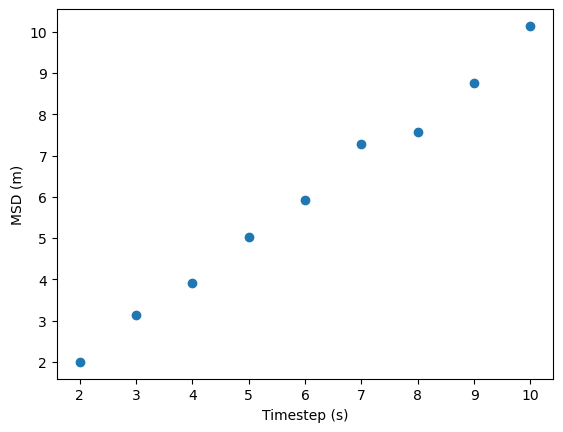

In [91]:
particle1 = generate_trajectory(1000, starting_position)
particle1_data = generate_MSD_dataset(10, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

However, closer to actual Brownian motion, the magnitude of displacement need not be constant all the time… Instead it may be a more realistic simulation to choose a magnitude of displacement from a normal distribution for each time step. 

In [92]:
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    #displacement= np.random.normal(loc=1, scale=2)
    #angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = np.random.normal(loc=0, scale=1)
    y_direction = np.random.normal(loc=0, scale=1)
    #print(x_direction, y_direction)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [93]:
generate_direction_vector()

[0.4269504624796305, -0.6912149650273891]

Text(0, 0.5, 'MSD (m)')

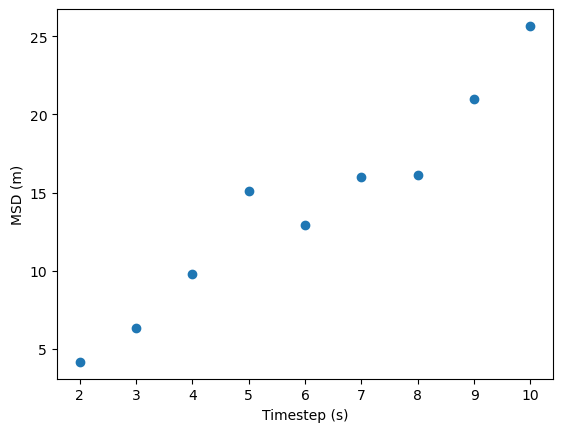

In [104]:
particle1 = generate_trajectory(100, starting_position)
particle1_data = generate_MSD_dataset(10, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

Text(0, 0.5, 'MSD (m)')

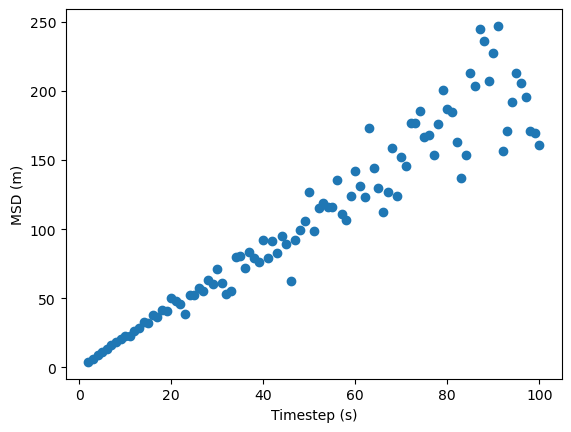

In [107]:
particle1 = generate_trajectory(1000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

Text(0, 0.5, 'MSD (m)')

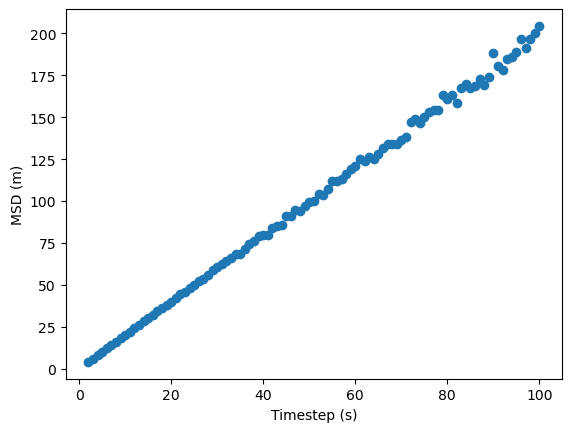

In [109]:
particle1 = generate_trajectory(100000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

Text(0, 0.5, 'MSD (m)')

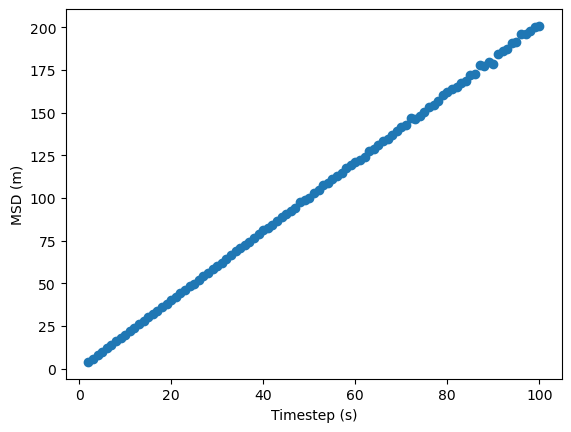

In [110]:
particle1 = generate_trajectory(1000000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

What happens when we enforce boundaries on how far the particle can actually travel? Will that change the shape of the MSD on time graph? 

In [ ]:
"""
(-5, 5) -------- (5,5)
|
|
|
|
(-5, -5) -------- (-5,5)

"""

def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return np.array([x_direction, y_direction])

def rebound_at_boundary(boundary_x, boundary_y, next_step):
    #rightcorner
    magnitude = abs(next_step)
    boundary_violated = magnitude - np.array([boundary_x, boundary_y]) > np.array([0,0])
    x = next_step[0]
    y = next_step[1]
    if boundary_violated[0]:
        if x > 0:
            x = boundary_x - (x - boundary_x)
        else:
            x = -boundary_x - (x + boundary_x) 
    if boundary_violated[1]:
        if y > 0:
            y = boundary_y - (y - boundary_y)
        else:
            y = -boundary_y - (y + boundary_y)
    return np.array([x,y])
 
def generate_trajectory(time, starting_position, boundary_x, boundary_y):
    trajectory = [np.concatenate((np.array([0]), starting_position))]
    current_position = starting_position.copy()
    current_time = 0
    while current_time < time:
        current_time += 1
        next_step = current_position + generate_direction_vector().copy()
        current_position = rebound_at_boundary(boundary_x, boundary_y, next_step)
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
    return trajectory 

In [ ]:
boundary_x = 1
boundary_y = 1
trajectory1 = generate_trajectory(100, np.array([0,0], dtype=float), boundary_x, boundary_y)
print(trajectory1)

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]


particle1 = generate_trajectory(1000000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 2
boundary_y = 2

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 5
boundary_y = 5

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 10
boundary_y = 10

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 100
boundary_y = 100

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


Clearly, as the boundary of the container increases, the behaviour of the graph tends to what we would expect without boundary in part 1 (boundary of the graph goes to infinity). 
Otherwise, for a small enough container, the MSD plateaus after a certain threshold in time. Why?

In [ ]:
%pip install ipympl

In [ ]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

#will attempt to use the langevin model to simulate the motion of the tagged particle. This will also require setting the visosity of the fluid. 

container_length = 10 #set size of container 
number_of_particles = 3 #number of background particles 
viscosity_of_fluid = 1 #the visosity of fluid needed to compute drag on tagged particle
velocity_tagged = 0 #the velocity of the tagged particle 
velocity_background = 1 #the average velocity of the bakground particle, proportional to temeprature. For sake of simulation, we will assume the bacground particles to be travelling at constant velocity. 
time_difference = 1 #modify later, default to 1s between frames for now. 

background_particle_history = []
tagged_particle_history = []

tagged_particle_pos = np.array([container_length/2,container_length/2], dtype=float) #initialise position of tagged particle to be at the centre of the container 

#initialises a particular arrangement of the background particles for given number of background particles and container size (square)
def initialise_background(number_of_particles, container_length):
    background_initial = []
    for number in range(number_of_particles):
        x_coordinate = np.random.uniform(0, container_length)
        y_coordinate = np.random.uniform(0, container_length)
        background_initial.append(np.array([x_coordinate, y_coordinate]))
    return background_initial

#to generate the random motion of the background particles 
def generate_direction_vector(velocity_background, time_difference):
    magnitude = velocity_background*time_difference
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = magnitude*math.cos(angle)
    y_direction = magnitude*math.sin(angle)
    return np.array([x_direction, y_direction])

def rebound_at_boundary(boundary_x, boundary_y, next_step):
    #rightcorner
    magnitude = abs(next_step)
    boundary_violated = magnitude - np.array([boundary_x, boundary_y]) > np.array([0,0])
    x = next_step[0]
    y = next_step[1]
    if boundary_violated[0]:
        if x > 0:
            x = boundary_x - (x - boundary_x)
        else:
            x = -boundary_x - (x + boundary_x) 
    if boundary_violated[1]:
        if y > 0:
            y = boundary_y - (y - boundary_y)
        else:
            y = -boundary_y - (y + boundary_y)
    return np.array([x,y])

def update_background_position(background_history):
    next_frame = []
    for frame in background_history:
        for particle in frame:
            print(particle)
            hypothetical = particle + generate_direction_vector(velocity_background, time_difference).copy()
            actual_position = rebound_at_boundary(container_length, container_length, hypothetical)
            next_frame.append(actual_position)
    return np.array(next_frame)
    

In [ ]:
initialised = initialise_background(3, 10)
plt.clf()
plt.scatter(np.array(initialised)[:,0], np.array(initialised)[:,1])
plt.xlabel('x (m)')
plt.ylabel('y (m)' )
plt.show()

In [ ]:
background_particle_history = []
background_particle_history.append(initialise_background(3, 10))
background_particle_history.append(update_background_position(background_particle_history))

print(background_particle_history)